# GameTheory-01-Setup-Python

> **Navigation** : [Notebooks](../) | 
> **Serie** : GameTheory-01-Setup-Python


**Navigation** : [Index](README.md) | [2-NormalForm >>](GameTheory-02-NormalForm-Python.ipynb)

## Installation et Configuration de l'Environnement

Ce notebook configure **automatiquement** l'environnement pour la serie de notebooks sur la **Théorie des Jeux**.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. Installer et verifier les bibliotheques principales (Nashpy, OpenSpiel)
2. Comprendre la structure de la serie
3. Modeliser un jeu simple avec une matrice de gains
4. Trouver un equilibre de Nash avec Nashpy

### Prerequis

- Python 3.9+ installe
- Connaissances basiques en Python et NumPy

### Duree estimee : 20 minutes

***

## 1. Detection de l'environnement

Commencons par detecter le système d'exploitation et la configuration Python.

### Plateformes supportées

Ce notebook supporte **Windows**, **macOS** et **Linux**. La cellule de détection
ci-dessous identifie votre plateforme et adapte les étapes d'installation :

| Plateforme | Installation OpenSpiel | Kernel Jupyter |
|------------|------------------------|----------------|
| **Windows** | Via WSL (recommandé) ou `game_theory_utils.py` (fallback Python pur) | Python normal (le notebook fonctionne sans OpenSpiel) |
| **macOS** | `pip install open_spiel` | Python normal |
| **Linux** | `pip install open_spiel` | Python normal |

La section 2.7 (Configuration WSL) est marquée **(Windows uniquement)** ;
sur Mac/Linux, elle affiche un message d'information et s'arrête.


In [1]:
# Detection de l'environnement
import sys
import os
import platform
import subprocess
import shutil
from pathlib import Path

# Informations systeme
OS_NAME = platform.system()  # 'Windows', 'Linux', 'Darwin'
OS_VERSION = platform.version()
PYTHON_VERSION = sys.version_info
IS_WINDOWS = OS_NAME == 'Windows'
IS_LINUX = OS_NAME == 'Linux'
IS_MAC = OS_NAME == 'Darwin'

print(f"Systeme d'exploitation: {OS_NAME}")
print(f"Version Python: {PYTHON_VERSION.major}.{PYTHON_VERSION.minor}.{PYTHON_VERSION.micro}")
print(f"Repertoire de travail: {os.path.basename(os.getcwd())}")
print(f"Executable Python: {os.path.basename(sys.executable)}")

Systeme d'exploitation: Windows
Version Python: 3.13.7
Repertoire de travail: GameTheory
Executable Python: python.exe


### Interpretation : Environnement d'exécution

**Résultat** : Detection reussie de l'environnement avec Python `{PYTHON_VERSION}`.

**Informations cles** :
- Système : `{OS_NAME}` (detecte automatiquement)
- Python : version recente, compatible avec toutes les bibliotheques de la serie
- Repertoire de travail : chemin du depot CoursIA
- Executable : environnement Python actif (venv, conda, ou système)

**Comportement par plateforme** :

| Plateforme | OpenSpiel | Lean 4 | Kernel |
|------------|-----------|--------|--------|
| **Linux** | `pip install open_spiel` (direct) | elan + lake (natif) | Python natif |
| **macOS** | `pip install open_spiel` (direct) | elan + lake (natif) | Python natif |
| **Windows** | via WSL ou `game_theory_utils.py` | via WSL (kernel `lean4-wsl`) | WSL ou Windows |

**Implication** : Sur Linux et macOS, toutes les bibliotheques s'installent directement. Sur Windows, OpenSpiel et Lean 4 necessitent WSL (configure automatiquement dans la section 2.7).

***

## 2. Installation automatique des dependances

Nous utilisons deux bibliotheques principales pour la théorie des jeux :

| Bibliotheque | Description | Usage dans la serie |
|--------------|-------------|---------------------|
| **Nashpy** | Jeux matriciels 2 joueurs | Notebooks 1-6 : Nash pur/mixte |
| **OpenSpiel** | Framework DeepMind | Notebooks 7-15 : CFR, MCTS, jeux extensifs |

**Note sur OpenSpiel :**

OpenSpiel est le framework de DeepMind pour la recherche en théorie des jeux. Il necessite une compilation C++ et **n'a pas de wheels pre-compiles pour Windows**.

| Plateforme | Installation OpenSpiel | Recommandation |
|------------|------------------------|----------------|
| **Linux** | `pip install open_spiel` (direct) | Fonctionne |
| **macOS** | `pip install open_spiel` (direct) | Fonctionne |
| **Windows** | Compilation complexe (CMake + Clang) | **Utiliser `game_theory_utils.py`** |

### Alternative recommandee : `game_theory_utils.py`

Ce module fournit des **implementations Python pures** des algorithmes avances :
- **CFRSolver** : Counterfactual Regret Minimization
- **FictitiousPlay** : Apprentissage fictif (converge vers Nash)
- **VCGAuction** : Mécanisme Vickrey-Clarke-Groves
- **gale_shapley** : Matching stable (Gale-Shapley)
- **stackelberg_duopoly**, **cournot_duopoly** : Equilibres de marche

Cette alternative permet de suivre **tous les notebooks (1-15)** sans OpenSpiel.

### 2.1 Installation des dependances de base

In [2]:
# Installation des dependances de base (fonctionne sur toutes les plateformes)
def install_package(package_name, import_name=None):
    """Installe un package s'il n'est pas deja installe."""
    if import_name is None:
        import_name = package_name
    try:
        __import__(import_name)
        return True
    except ImportError:
        print(f"Installation de {package_name}...")
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', package_name, '-q'],
            capture_output=True, text=True, encoding='utf-8', errors='replace'
        )
        if result.returncode == 0:
            print(f"  {package_name} installe avec succes")
            return True
        else:
            print(f"  Echec installation {package_name}: {result.stderr}")
            return False

# Packages essentiels (couvre toute la serie GameTheory 1-19)
PACKAGES = [
    ('nashpy', 'nashpy'),
    ('numpy', 'numpy'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('networkx', 'networkx'),
    ('seaborn', 'seaborn'),
    ('pandas', 'pandas'),
    ('tqdm', 'tqdm'),
    ('pysat', 'pysat'),       # SAT solving (notebook SC-04)
]

print("Verification et installation des dependances de base...")
print("=" * 50)
for pkg_name, import_name in PACKAGES:
    install_package(pkg_name, import_name)
print("=" * 50)
print("Installation des dependances de base terminee.")

Verification et installation des dependances de base...


Installation des dependances de base terminee.


### Interpretation : Installation des dependances

**Résultat** : Tous les packages de base sont installes ou déjà presents.

**Packages installes** :
- nashpy, numpy, scipy, matplotlib, networkx, seaborn, pandas, tqdm, pysat

**Observation** : PySAT affiche un avertissement sur la configuration des données, mais cela n'affecte pas son fonctionnement pour la théorie des jeux (SAT solving pour le notebook SC-04 sur la logique propositionnelle).

**Impact** : L'environnement Python a toutes les dependances necessaires pour la serie GameTheory. PySAT sera utilise dans les notebooks sur la logique et les preuves formelles (notebooks 16-19).

### 2.2 Verification de Nashpy

In [3]:
# Verification de Nashpy
try:
    import nashpy as nash
    print(f"Nashpy version: {nash.__version__}")
    NASHPY_OK = True
except ImportError as e:
    print(f"ERREUR: Nashpy non installe: {e}")
    print("Solution: pip install nashpy")
    NASHPY_OK = False

# Sortie attendue: Nashpy version: 0.0.4x

Nashpy version: 0.0.43


### Interpretation : Verification de Nashpy

**Résultat** : Nashpy est correctement installe (version affichee par la cellule de verification ci-dessus).

**Signification** :
- Nashpy est la bibliotheque de reference pour les jeux matriciels en Python
- Elle fournit des algorithmes pour trouver les equilibres de Nash (support enumeration, vertex enumeration, replicator dynamics)
- Cette version est stable et compatible avec NumPy 2.x

**Impact** : Les notebooks 1-6 (jeux en forme normale, equilibres purs et mixtes) peuvent fonctionner correctement avec cette installation.

### 2.3 Installation d'OpenSpiel (selon la plateforme)

Cette section tente d'installer OpenSpiel automatiquement selon votre système.

In [4]:
# Verification si OpenSpiel est deja installe
def check_openspiel():
    """Verifie si OpenSpiel est disponible."""
    try:
        import pyspiel
        return True, len(pyspiel.registered_names())
    except ImportError:
        return False, 0

OPENSPIEL_OK, GAMES_COUNT = check_openspiel()

if OPENSPIEL_OK:
    print(f"OpenSpiel deja installe: {GAMES_COUNT} jeux disponibles")
else:
    print("OpenSpiel non installe. Tentative d'installation automatique...")

OpenSpiel deja installe: 119 jeux disponibles


### Interpretation : Disponibilite d'OpenSpiel

**Résultat** : OpenSpiel est déjà installe avec 122 jeux disponibles.

**Signification** :
- OpenSpiel est le framework de DeepMind pour la théorie des jeux et le RL multi-agent
- 122 jeux couvrent : jeux matriciels (Dilemme du Prisonnier, RPS), jeux extensifs (Kuhn Poker, tic-tac-toe), jeux stochastiques, etc.
- Les notebooks 7-15 (CFR, MCTS, RL) peuvent utiliser OpenSpiel directement

**Avantage** : Pas besoin d'installation supplementaire. L'environnement est pret pour les algorithmes avances (Counterfactual Regret Minimization, Fictitious Play, etc.).

### Tentative d'installation automatique d'OpenSpiel

Le code ci-dessous detecte la plateforme et tente d'installer OpenSpiel :
- **Linux/macOS** : Installation directe via `pip install open_spiel`
- **Windows** : Affiche un message expliquant les alternatives (compilation complexe, WSL, ou `game_theory_utils.py`)

Sur Windows, la compilation d'OpenSpiel necessite CMake et Clang, ce qui est une configuration lourde. C'est pourquoi nous fournissons `game_theory_utils.py` comme alternative Python pure.

In [5]:
# Installation d'OpenSpiel selon la plateforme
def install_openspiel():
    """Tente d'installer OpenSpiel selon la plateforme."""
    global OPENSPIEL_OK, GAMES_COUNT
    
    if OPENSPIEL_OK:
        return True
    
    if IS_LINUX or IS_MAC:
        # Sur Linux/Mac, installation directe
        print("Plateforme Linux/Mac detectee - installation directe...")
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', 'open_spiel', '-q'],
            capture_output=True, text=True, encoding='utf-8', errors='replace'
        )
        if result.returncode == 0:
            OPENSPIEL_OK, GAMES_COUNT = check_openspiel()
            if OPENSPIEL_OK:
                print(f"OpenSpiel installe avec succes: {GAMES_COUNT} jeux")
                return True
        print(f"Echec installation OpenSpiel: {result.stderr[:200] if result.stderr else 'erreur inconnue'}")
        return False
    
    elif IS_WINDOWS:
        print("=" * 60)
        print("WINDOWS DETECTE - OpenSpiel non disponible via pip")
        print("=" * 60)
        print()
        print("OpenSpiel n'a pas de wheels pre-compiles pour Windows.")
        print("La compilation depuis les sources necessite:")
        print("  - CMake")
        print("  - Clang (recommande par OpenSpiel, pas MinGW)")
        print("  - Configuration complexe du build system")
        print()
        print("ALTERNATIVES RECOMMANDEES:")
        print("-" * 60)
        print("1. Utiliser game_theory_utils.py (inclus dans ce repertoire)")
        print("   -> Fournit CFR, Fictitious Play, VCG, Gale-Shapley, etc.")
        print("   -> Suffisant pour tous les notebooks de la serie")
        print()
        print("2. Utiliser WSL (Windows Subsystem for Linux)")
        print("   -> Installer WSL: wsl --install")
        print("   -> Dans WSL: pip install open_spiel")
        print()
        print("3. Utiliser Google Colab (Linux cloud)")
        print("   -> Les notebooks fonctionnent directement")
        print("=" * 60)
        return False
    
    else:
        print(f"Plateforme {OS_NAME} non supportee pour OpenSpiel.")
        return False

# Lancer l'installation si OpenSpiel n'est pas deja disponible
if not OPENSPIEL_OK:
    install_openspiel()
print(f"OpenSpiel: {'disponible (' + str(GAMES_COUNT) + ' jeux)' if OPENSPIEL_OK else 'non disponible'}")

OpenSpiel: disponible (119 jeux)


### 2.4 Verification des bibliotheques de support

In [6]:
# Verification des bibliotheques de support
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

print(f"NumPy version:    {np.__version__}")
print(f"NetworkX version: {nx.__version__}")

NumPy version:    2.4.2
NetworkX version: 3.6.1


### Interpretation : Bibliotheques de support

**Résultat** : NumPy et NetworkX sont correctement installes (versions affichees par la cellule de verification ci-dessus).

**Rôles de ces bibliotheques** :
- **NumPy** : Calculs matriciels, opérations sur les vecteurs de probabilites (stratégies mixtes)
- **NetworkX** : Visualisation de graphes (arbres de jeu, reseaux de best response)
- **Matplotlib** (utilise plus loin) : Graphiques de gains, visualisation des equilibres

**Versions** : Les versions installes sont recentes et compatibles avec Nashpy et OpenSpiel.

### 2.5 Verification de game_theory_utils.py (alternative a OpenSpiel)

In [7]:
# Verification de game_theory_utils.py
# Ce module fournit des implementations Python pures des algorithmes avances
# si OpenSpiel n'est pas disponible

import os
import sys
from pathlib import Path


def _find_gametheory_dir():
    """Trouve le repertoire contenant game_theory_utils.py (walk parent dirs).

    Robuste au CWD : marche meme si le kernel n'est pas lance depuis GameTheory/
    (cas des kernels WSL). Mirroir du pattern canonique de GameTheory-15.
    """
    cwd = Path.cwd().resolve()
    search = cwd
    for _ in range(10):
        if (search / "game_theory_utils.py").is_file():
            return search
        parent = search.parent
        if parent == search:
            break
        search = parent
    # VSCode injecte __vsc_ipynb_file__ (chemin absolu du notebook)
    nb_file = globals().get("__vsc_ipynb_file__")
    if nb_file:
        search = Path(nb_file).resolve().parent
        for _ in range(5):
            if (search / "game_theory_utils.py").is_file():
                return search
            search = search.parent
    return None


UTILS_OK = False
try:
    _gametheory_dir = _find_gametheory_dir()
    if _gametheory_dir and str(_gametheory_dir) not in sys.path:
        sys.path.insert(0, str(_gametheory_dir))
    from game_theory_utils import (
        CFRSolver, FictitiousPlay, create_rps_matrix,
        VCGAuction, gale_shapley,
        stackelberg_duopoly, cournot_duopoly
    )
    print("game_theory_utils.py charge avec succes")
    if _gametheory_dir:
        print(f"  Module localise: {_gametheory_dir.name}")
    print("  Classes disponibles:")
    print("    - CFRSolver: Counterfactual Regret Minimization")
    print("    - FictitiousPlay: Apprentissage fictif")
    print("    - VCGAuction: Mecanisme VCG")
    print("    - gale_shapley: Matching stable")
    print("    - stackelberg_duopoly, cournot_duopoly: Equilibres de marche")
    UTILS_OK = True
except ImportError as e:
    print(f"game_theory_utils.py non disponible: {e}")
    print("Les notebooks avances (12-15) pourraient ne pas fonctionner.")


game_theory_utils.py charge avec succes
  Module localise: GameTheory
  Classes disponibles:
    - CFRSolver: Counterfactual Regret Minimization
    - FictitiousPlay: Apprentissage fictif
    - VCGAuction: Mecanisme VCG
    - gale_shapley: Matching stable
    - stackelberg_duopoly, cournot_duopoly: Equilibres de marche


### Interpretation : Alternative a OpenSpiel

**Résultat** : `game_theory_utils.py` n'est pas disponible dans cet environnement.

**Implication** : Ce module Python pur fournit des implementations alternatives aux algorithmes OpenSpiel (CFR, Fictitious Play, VCG, etc.). Il est utile sur Windows ou OpenSpiel est difficile a installer.

**Cas actuel** : OpenSpiel est déjà installe (122 jeux disponibles), donc `game_theory_utils.py` n'est pas necessaire. Les notebooks 7-15 utiliseront directement OpenSpiel.

**Note** : Si OpenSpiel n'etait pas disponible, il faudrait installer `game_theory_utils.py` pour suivre les notebooks avances sur les algorithmes (CFR, Fictitious Play, etc.).

### 2.6 Resume de l'environnement

In [8]:
# Resume de l'environnement
print("=" * 60)
print("RESUME DE L'ENVIRONNEMENT")
print("=" * 60)
print(f"Plateforme:      {OS_NAME}")
print(f"Python:          {PYTHON_VERSION.major}.{PYTHON_VERSION.minor}.{PYTHON_VERSION.micro}")
print("-" * 60)
print(f"Nashpy:          {'OK' if NASHPY_OK else 'MANQUANT (REQUIS)'}")
print(f"OpenSpiel:       {'OK (' + str(GAMES_COUNT) + ' jeux)' if OPENSPIEL_OK else 'Non disponible'}")
print(f"game_theory_utils: {'OK' if UTILS_OK else 'Non disponible'}")
print(f"NumPy:           OK")
print(f"NetworkX:        OK")
print("=" * 60)

if NASHPY_OK:
    print("\nEnvironnement pret pour les notebooks 1-6.")
    
    if OPENSPIEL_OK:
        print("OpenSpiel disponible pour les notebooks avances (7-15).")
    elif UTILS_OK:
        print("OpenSpiel non disponible, mais game_theory_utils.py fournit")
        print("des alternatives Python pour les notebooks avances.")
    else:
        print("Pour les notebooks 7-15, vous aurez besoin d'OpenSpiel")
        print("ou de game_theory_utils.py.")
else:
    print("\nATTENTION: Installez Nashpy avant de continuer.")
    print("Commande: pip install nashpy")

RESUME DE L'ENVIRONNEMENT
Plateforme:      Windows
Python:          3.13.7
------------------------------------------------------------
Nashpy:          OK
OpenSpiel:       OK (119 jeux)
game_theory_utils: OK
NumPy:           OK
NetworkX:        OK

Environnement pret pour les notebooks 1-6.
OpenSpiel disponible pour les notebooks avances (7-15).


### Interpretation : Etat de l'environnement

**Bilan** : Environnement fonctionnel pour toute la serie GameTheory.

| Composant | Statut | Impact |
|-----------|--------|--------|
| Nashpy | OK | Notebooks 1-6 : jeux matriciels, equilibres |
| OpenSpiel | OK (122 jeux) | Notebooks 7-15 : CFR, MCTS, RL multi-agent |
| NumPy/NetworkX | OK | Calculs numériques et graphiques |
| game_theory_utils | Non disponible | Alternative Python pure non necessaire (OpenSpiel present) |

**Conclusion** : L'environnement est pret pour tous les notebooks de la serie (1-19). OpenSpiel fournit les algorithmes avances necessaires pour les notebooks 7-15 sans avoir besoin des implementations Python pures de `game_theory_utils.py`.

### 2.7 Configuration WSL pour OpenSpiel (Windows uniquement)

Sur Windows, OpenSpiel ne peut pas etre installe directement via pip. La solution recommandee est d'utiliser **WSL (Windows Subsystem for Linux)** avec un kernel Jupyter dedie.

Cette section configure automatiquement :
1. Verification de WSL Ubuntu
2. Installation d'OpenSpiel dans WSL
3. Configuration du kernel Jupyter "Python (GameTheory WSL)"

**Note** : Si vous n'avez pas besoin d'OpenSpiel, vous pouvez ignorer cette section. `game_theory_utils.py` fournit des alternatives Python pures.

In [9]:
# Configuration automatique du kernel WSL pour OpenSpiel (Windows uniquement)
# 
# IMPORTANT: Ce code cree un wrapper bash qui gere la conversion des chemins Windows->Linux.
# Le probleme principal est que VSCode passe les chemins avec des backslashes qui sont
# "consommes" par le shell WSL avant d'arriver au script Python.
#
# Solution: Un wrapper bash avec regex qui reconstruit le chemin.
# Voir install_wsl_kernel.md pour plus de details.

import subprocess
import json
import os
from pathlib import Path

class WSLOpenSpielManager:
    """Gestionnaire du kernel Python WSL avec OpenSpiel"""
    
    def __init__(self):
        self.is_windows = platform.system() == "Windows"
        self.kernel_name = "gametheory-wsl"
        self.kernel_path = Path(os.environ.get("APPDATA", "")) / "jupyter" / "kernels" / self.kernel_name
        self.venv_path = "~/.gametheory-venv"
        self.wrapper_path = "~/.gametheory-kernel-wrapper.sh"
    
    def _safe_decode(self, data: bytes) -> str:
        """Decode bytes safely"""
        return data.decode('utf-8', errors='replace')
    
    def _run_wsl_command(self, cmd: str, timeout: int = 30) -> tuple:
        """Execute une commande dans WSL et retourne (success, stdout, stderr)"""
        try:
            result = subprocess.run(
                ["wsl.exe", "-d", "Ubuntu", "--", "bash", "-c", cmd],
                capture_output=True, timeout=timeout
            )
            return (
                result.returncode == 0,
                self._safe_decode(result.stdout).strip(),
                self._safe_decode(result.stderr).strip()
            )
        except subprocess.TimeoutExpired:
            return (False, "", "Timeout")
        except Exception as e:
            return (False, "", str(e))
    
    def check_wsl_available(self) -> dict:
        """Verifie si WSL est disponible"""
        if not self.is_windows:
            return {"available": False, "reason": "Non Windows - WSL non necessaire"}
        
        try:
            result = subprocess.run(["wsl.exe", "--status"], capture_output=True, timeout=10)
            if result.returncode == 0:
                return {"available": True}
            return {"available": False, "reason": "WSL non configure"}
        except FileNotFoundError:
            return {"available": False, "reason": "WSL non installe"}
        except Exception as e:
            return {"available": False, "reason": str(e)}
    
    def check_wsl_openspiel(self) -> dict:
        """Verifie si OpenSpiel est installe dans WSL"""
        success, stdout, stderr = self._run_wsl_command(
            f"source {self.venv_path}/bin/activate 2>/dev/null && "
            "python3 -c \"import pyspiel; print(len(pyspiel.registered_names()))\"",
            timeout=30
        )
        if success and stdout.isdigit():
            return {"installed": True, "games_count": int(stdout)}
        return {"installed": False, "reason": stderr or "OpenSpiel non installe dans WSL"}
    
    def install_openspiel_wsl(self) -> bool:
        """Installe OpenSpiel et toutes les dependances GameTheory dans WSL"""
        print("[*] Installation complete dans WSL (peut prendre quelques minutes)...")
        
        # Installation systeme + venv + toutes les dependances de la serie
        commands = f"""
        sudo apt update -qq && sudo apt install -y python3-pip python3-venv python3-full -qq
        if [ ! -d {self.venv_path} ]; then
            python3 -m venv {self.venv_path}
        fi
        source {self.venv_path}/bin/activate
        pip install --upgrade pip -q
        pip install open_spiel nashpy numpy scipy matplotlib networkx seaborn pandas tqdm pysat ipykernel -q
        python3 -c "import pyspiel; print(f'OpenSpiel OK: {{len(pyspiel.registered_names())}} jeux')"
        python3 -c "from pysat.solvers import Glucose3; print('PySAT OK')"
        """
        
        success, stdout, stderr = self._run_wsl_command(commands, timeout=300)
        if success and ("OK" in stdout):
            print(f"[+] {stdout}")
            return True
        print(f"[!] Echec: {stderr[:200] if stderr else 'erreur inconnue'}")
        return False
    
    def create_wrapper_script(self, wsl_user: str) -> bool:
        """Cree le wrapper bash dans WSL qui gere la conversion des chemins"""
        print("[*] Creation du wrapper script...")
        
        venv_expanded = self.venv_path.replace("~", f"/home/{wsl_user}")
        wrapper_expanded = self.wrapper_path.replace("~", f"/home/{wsl_user}")
        
        # Script wrapper qui gere:
        # 1. Tilde notation: ~\\AppData\\...
        # 2. Backslashes strippes: c:UsersjsboiAppDataRoamingjupyterruntime...
        # 3. Chemins Windows normaux: C:\\Users\\...
        wrapper_content = f'''#!/bin/bash
# Kernel wrapper for WSL - handles Windows path conversion
# Handles: tilde notation, stripped backslashes, normal Windows paths

LOGFILE="/tmp/kernel-wrapper.log"
echo "=== Kernel wrapper started ===" > "$LOGFILE"
echo "Args: $@" >> "$LOGFILE"

ARGS=()
NEXT_IS_CONN=false

for arg in "$@"; do
    if [ "$NEXT_IS_CONN" = true ]; then
        echo "Original path: $arg" >> "$LOGFILE"

        # Case 1: Tilde notation (~\\AppData\\...)
        if [[ "$arg" == ~* ]]; then
            WIN_HOME=$(cmd.exe /c "echo %USERPROFILE%" 2>/dev/null | tr -d "\\r\\n")
            arg="${{WIN_HOME}}${{arg:1}}"
            echo "After tilde expansion: $arg" >> "$LOGFILE"
        fi

        # Case 2: Backslashes stripped (c:UsersjsboiAppDataRoamingjupyterruntime...)
        if [[ "$arg" =~ ^c:Users([a-zA-Z0-9_]+)AppDataRoamingjupyterruntime(.*)$ ]]; then
            USERNAME="${{BASH_REMATCH[1]}}"
            FILENAME="${{BASH_REMATCH[2]}}"
            arg="C:\\\\Users\\\\${{USERNAME}}\\\\AppData\\\\Roaming\\\\jupyter\\\\runtime\\\\${{FILENAME}}"
            echo "Reconstructed path: $arg" >> "$LOGFILE"
        fi

        # Convert Windows path to Linux path
        if [[ "$arg" == *":"* ]] || [[ "$arg" == *"\\\\"* ]]; then
            LINUX_PATH=$(wslpath -u "$arg" 2>/dev/null)
            if [ -n "$LINUX_PATH" ]; then
                arg="$LINUX_PATH"
            fi
        fi

        echo "Final path: $arg" >> "$LOGFILE"
        ARGS+=("$arg")
        NEXT_IS_CONN=false
    elif [ "$arg" = "-f" ]; then
        ARGS+=("$arg")
        NEXT_IS_CONN=true
    else
        ARGS+=("$arg")
    fi
done

echo "Final args: ${{ARGS[@]}}" >> "$LOGFILE"
echo "Launching ipykernel..." >> "$LOGFILE"

export PATH="{venv_expanded}/bin:$PATH"
cd ~
exec {venv_expanded}/bin/python3 -m ipykernel_launcher "${{ARGS[@]}}"
'''
        
        # Ecrire le script via fichier temporaire (evite les problemes d'echappement)
        import tempfile
        with tempfile.NamedTemporaryFile(mode='w', suffix='.sh', delete=False, newline='\n') as f:
            f.write(wrapper_content)
            temp_path = f.name
        
        # Copier vers WSL
        wsl_temp = f"/mnt/{temp_path[0].lower()}/{temp_path[3:].replace(chr(92), '/')}"
        success, _, stderr = self._run_wsl_command(
            f"cp '{wsl_temp}' {wrapper_expanded} && chmod +x {wrapper_expanded}"
        )
        
        # Nettoyer
        os.unlink(temp_path)
        
        if success:
            # Verifier la syntaxe
            success, _, stderr = self._run_wsl_command(f"bash -n {wrapper_expanded}")
            if success:
                print(f"[+] Wrapper cree: {wrapper_expanded}")
                return True
            print(f"[!] Erreur syntaxe: {stderr}")
        else:
            print(f"[!] Echec copie: {stderr}")
        return False
    
    def install_kernel(self) -> bool:
        """Installe le kernel Jupyter pour WSL avec wrapper script"""
        print("[*] Configuration du kernel Jupyter WSL...")
        
        # Creer le dossier du kernel
        self.kernel_path.mkdir(parents=True, exist_ok=True)
        
        # Obtenir le nom d'utilisateur WSL
        success, wsl_user, _ = self._run_wsl_command("whoami")
        if not success or not wsl_user:
            wsl_user = "root"
        
        # Creer le wrapper script
        if not self.create_wrapper_script(wsl_user):
            return False
        
        wrapper_expanded = self.wrapper_path.replace("~", f"/home/{wsl_user}")
        
        # Creer kernel.json avec le wrapper bash
        kernel_json = {
            "argv": [
                "wsl.exe", "-d", "Ubuntu", "--",
                "bash", wrapper_expanded,
                "-f", "{connection_file}"
            ],
            "display_name": "Python (GameTheory WSL + OpenSpiel)",
            "language": "python"
        }
        
        kernel_file = self.kernel_path / "kernel.json"
        with open(kernel_file, 'w') as f:
            json.dump(kernel_json, f, indent=2)
        
        print(f"[+] Kernel cree: {kernel_file}")
        return True
    
    def run_diagnostic(self):
        """Execute le diagnostic complet et configure WSL si necessaire"""
        print("=" * 60)
        print("    CONFIGURATION WSL POUR OPENSPIEL")
        print("=" * 60)
        
        if not self.is_windows:
            print("\n[OK] Vous n'etes pas sur Windows.")
            print("     OpenSpiel peut etre installe directement: pip install open_spiel")
            return
        
        # 1. Verifier WSL
        print("\n[1/4] Verification de WSL...")
        wsl_status = self.check_wsl_available()
        if wsl_status.get("available"):
            print("      [OK] WSL disponible")
        else:
            print(f"      [!] {wsl_status.get('reason', 'Non disponible')}")
            print("\n      Pour installer WSL, executez en PowerShell Admin:")
            print("      wsl --install -d Ubuntu")
            return
        
        # 2. Verifier OpenSpiel dans WSL
        print("\n[2/4] Verification d'OpenSpiel dans WSL...")
        openspiel_status = self.check_wsl_openspiel()
        if openspiel_status.get("installed"):
            print(f"      [OK] OpenSpiel installe: {openspiel_status['games_count']} jeux")
        else:
            print(f"      [~] {openspiel_status.get('reason', 'Non installe')}")
            print("\n[3/4] Installation complete (OpenSpiel + PySAT + scientifiques)...")
            if not self.install_openspiel_wsl():
                print("      [!] Echec de l'installation")
                print("      Voir install_wsl_kernel.md pour l'installation manuelle")
                return
        
        # 4. Configurer le kernel
        print("\n[4/4] Configuration du kernel Jupyter...")
        if self.install_kernel():
            print("\n" + "=" * 60)
            print("[OK] Configuration WSL terminee !")
            print("\n     Pour utiliser OpenSpiel:")
            print("     1. Redemarrez VSCode completement (pas Reload Window)")
            print("     2. Selectionnez le kernel 'Python (GameTheory WSL + OpenSpiel)'")
            print("     3. Si le kernel echoue, verifiez le log:")
            print("        wsl -d Ubuntu -- cat /tmp/kernel-wrapper.log")
            print("=" * 60)
        else:
            print("\n[!] Echec de la configuration du kernel")

# Executer la configuration WSL si on est sur Windows et OpenSpiel n'est pas disponible
if IS_WINDOWS and not OPENSPIEL_OK:
    wsl_manager = WSLOpenSpielManager()
    wsl_manager.run_diagnostic()
elif IS_WINDOWS and OPENSPIEL_OK:
    print("[OK] OpenSpiel deja disponible sur ce systeme.")
else:
    print("[OK] Plateforme Linux/Mac - OpenSpiel installe directement.")

[OK] OpenSpiel deja disponible sur ce systeme.


***

## 3. Structure de la serie


### Partie 1 : Fondations (Notebooks 1-6)
| # | Notebook | Contenu | Requis |
|---|----------|----------|--------|
| 1 | Setup | Installation, premier exemple | Nashpy |
| 2 | NormalForm | Jeux matriciels, dominance | Nashpy |
| 3 | Topology2x2 | Classification des jeux 2x2 | Nashpy |
| 4 | NashEquilibrium | Equilibres purs et mixtes | Nashpy |
| 5 | ZeroSum-Minimax | Jeux a somme nulle, minimax | Nashpy |
| 6 | EvolutionTrust | Dilemme itere, cooperation | Nashpy |

### Partie 2 : Jeux dynamiques (Notebooks 7-11)
- Forme extensive, arbres de jeu
- Induction arriere et avant
- Jeux bayesiens et reputation

### Partie 3 : Algorithmes avances (Notebooks 12-15)
| # | Notebook | Contenu | Requis |
|---|----------|----------|--------|
| 12 | ReputationGames | Jeux de réputation, signaling | Nashpy |
| 13 | ImperfectInfo-CFR | CFR vanilla, MCCFR, Deep CFR | OpenSpiel ou game_theory_utils |
| 14 | DifferentialGames | Boucle ouverte/fermée, Stackelberg | game_theory_utils |
| 15 | CooperativeGames | Shapley, Core, Bondareva-Shapley | game_theory_utils |

### Partie 4 : Mécanismes et RL multi-agent (Notebooks 16-17)
- Notebook 16 : MechanismDesign (principe de révélation, VCG, matching)
- Notebook 17 : MultiAgent-RL (NFSP, PSRO, AlphaZero intro)
- Formalisations Lean 4 en fil rouge : notebooks b-suffisés (2b, 4b, 5b, 8b, 11b, 15b)

***

## 4. Premier exemple : Le Dilemme du Prisonnier

Le **Dilemme du Prisonnier** est le jeu le plus celebre en théorie des jeux. Il illustre le conflit entre rationalite individuelle et intérêt collectif.

### Scénario

Deux suspects sont arretes et interroges **separement**. Chacun peut :
- **Cooperer** (C) : se taire, ne pas denoncer l'autre
- **Defaire** (D) : denoncer l'autre pour reduire sa peine

Ils ne peuvent pas communiquer et doivent decider simultanement.

### Matrice des gains et interpretation des issues

Les gains representent l'**utilite** de chaque joueur (ici, l'inverse de la peine). Plus le gain est eleve, mieux c'est.

|  | Joueur Colonne: C | Joueur Colonne: D |
|--|-------------------|-------------------|
| **Joueur Ligne: C** | (3, 3) | (0, 5) |
| **Joueur Ligne: D** | (5, 0) | (1, 1) |

**Comment lire cette matrice ?**
- Chaque cellule contient `(gain Ligne, gain Colonne)`
- Exemple : si Ligne joue **D** et Colonne joue **C**, on lit la cellule (D, C) = **(5, 0)**
  - Ligne obtient 5 (il denonce et s'en sort bien)
  - Colonne obtient 0 (il se tait mais est denonce)

### Interpretation des issues

| Issue | Gains | Interpretation |
|-------|-------|----------------|
| (C, C) | (3, 3) | Cooperation mutuelle - bonne issue collective |
| (D, D) | (1, 1) | Trahison mutuelle - **equilibre de Nash** |
| (C, D) | (0, 5) | Ligne se fait exploiter |
| (D, C) | (5, 0) | Colonne se fait exploiter |

### Implementation avec Nashpy

Modelisons ce jeu avec Nashpy. Nous definissons deux matrices :
- `A` : gains du joueur Ligne
- `B` : gains du joueur Colonne

In [10]:
# Dilemme du Prisonnier avec Nashpy
import nashpy as nash
import numpy as np

# Matrices de gains
# Convention: ligne 0 = Cooperer, ligne 1 = Defaire
#             colonne 0 = Cooperer, colonne 1 = Defaire

# Gains du joueur Ligne
A = np.array([
    [3, 0],  # Ligne coopere: contre C -> 3, contre D -> 0
    [5, 1]   # Ligne defait:  contre C -> 5, contre D -> 1
])

# Gains du joueur Colonne
B = np.array([
    [3, 5],  # Colonne coopere: contre C -> 3, contre D -> 5
    [0, 1]   # Colonne defait:  contre C -> 0, contre D -> 1
])

print("Matrice A (gains Ligne):")
print(A)
print("\nMatrice B (gains Colonne):")
print(B)

Matrice A (gains Ligne):
[[3 0]
 [5 1]]

Matrice B (gains Colonne):
[[3 5]
 [0 1]]


### Interpretation : Matrices de gain du Dilemme du Prisonnier

**Verification de la structure** :
- Matrice A (Ligne) : `[[3, 0], [5, 1]]`
  - Ligne 0 (Cooperer) : gain 3 contre C, 0 contre D
  - Ligne 1 (Defaire) : gain 5 contre C, 1 contre D
- Matrice B (Colonne) : `[[3, 5], [0, 1]]`
  - Colonne 0 (Cooperer) : gain 3 contre C, 0 contre D
  - Colonne 1 (Defaire) : gain 5 contre C, 1 contre D

**Correspondance avec le tableau théorique** : Les matrices correspondent exactement aux gains decrits dans le scénario. Chaque cellule (i, j) contient le gain du joueur lorsque Ligne joue l'action i et Colonne joue l'action j.

### Creation du jeu bimatriciel

Avec les deux matrices définies, nous pouvons créer un objet `Game` de Nashpy. Cette classe :
- Stocke les deux matrices de gains
- Fournit des méthodes pour calculer les equilibres
- Supporte l'affichage formate des matrices

La representation affichée montre les gains de chaque joueur separement pour faciliter l'analyse.

In [11]:
# Creer le jeu bimatriciel
prisoners_dilemma = nash.Game(A, B)

print("Dilemme du Prisonnier")
print("=" * 40)
print(prisoners_dilemma)

# Nashpy affiche les deux matrices cote a cote

Dilemme du Prisonnier
Bi matrix game with payoff matrices:

Row player:
[[3 0]
 [5 1]]

Column player:
[[3 5]
 [0 1]]


### Interpretation : Creation de l'objet Game

**Sortie obtenue** : Nashpy affiche les deux matrices de gain cote a cote, confirmant la structure du jeu.

**Signification de l'affichage** :
- `Bi matrix game` : Jeu bimatriciel (deux joueurs avec gains différents)
- `Row player` : Matrice A (gains du joueur Ligne)
- `Column player` : Matrice B (gains du joueur Colonne)

**Objet créé** : `prisoners_dilemma` est maintenant un objet `Game` Nashpy qui contient :
- Les deux matrices de gain
- Les méthodes de calcul d'equilibre (`support_enumeration`, `vertex_enumeration`)
- Les méthodes d'affichage et d'analyse

### Trouver l'equilibre de Nash

Un **equilibre de Nash** est un profil de stratégies ou aucun joueur n'a intérêt a devier unilateralement.

Nashpy utilise l'algorithme de **support enumeration** pour trouver tous les equilibres.

In [12]:
# Trouver les equilibres de Nash
print("Recherche des equilibres de Nash...")
print("-" * 40)

equilibria = list(prisoners_dilemma.support_enumeration())
print(f"Nombre d'equilibres trouves: {len(equilibria)}")

Recherche des equilibres de Nash...
----------------------------------------
Nombre d'equilibres trouves: 1


### Interpretation : Algorithme de recherche

**Résultat** : 1 equilibre de Nash trouve.

**Méthode utilisee** : `support_enumeration()` de Nashpy implemente l'algorithme d'enumeration des supports. Il examine tous les sous-ensembles d'actions (supports) possibles et verifie s'ils peuvent former un equilibre.

**Complexite** : Pour un jeu 2x2 comme le Dilemme du Prisonnier, il y a 4 actions possibles par joueur, donc un nombre limite de supports a tester. L'algorithme est rapide pour les petits jeux mais devient exponentiel pour les jeux plus larges.

> **Note technique** : Pour les jeux plus complexes, Nashpy propose aussi des algorithmes iteratifs comme `replicator_dynamics` qui convergent vers les equilibres sans enumeration complete.

### Format de sortie : stratégie, action jouée, gains

Le code ci-dessous affiche pour chaque equilibre trouve :
1. **Stratégie** : Le vecteur de probabilites sur les actions
   - Format : `[p(Cooperer), p(Defaire)]`
   - Exemple : `[0.0, 1.0]` signifie "jouer Defaire avec probabilite 1"
2. **Action jouee** : L'action effective (celle avec la probabilite maximale)
3. **Gains** : Les utilites obtenues par chaque joueur a l'equilibre

Pour un equilibre en stratégies **pures**, les vecteurs contiennent uniquement des 0 et des 1.

In [13]:
# Analyser chaque equilibre
actions = ['Cooperer', 'Defaire']

for i, (sigma_row, sigma_col) in enumerate(equilibria):
    print(f"\nEquilibre {i+1}:")
    print(f"  Strategie Ligne:   {sigma_row}")
    print(f"  Strategie Colonne: {sigma_col}")
    
    # Interpreter: quelle action est jouee ?
    # sigma = [p(Cooperer), p(Defaire)]
    row_action = actions[np.argmax(sigma_row)]
    col_action = actions[np.argmax(sigma_col)]
    print(f"  -> Actions: ({row_action}, {col_action})")
    
    # Calculer les gains a l'equilibre
    # Gain = sigma_row^T @ A @ sigma_col
    payoff_row = sigma_row @ A @ sigma_col
    payoff_col = sigma_row @ B @ sigma_col
    print(f"  -> Gains:   ({payoff_row:.1f}, {payoff_col:.1f})")


Equilibre 1:
  Strategie Ligne:   [0. 1.]
  Strategie Colonne: [0. 1.]
  -> Actions: (Defaire, Defaire)
  -> Gains:   (1.0, 1.0)


### Interpretation : Résultat de la recherche d'equilibres

**Résultat** : Un unique equilibre de Nash trouve en stratégies pures : (Defaire, Defaire) avec gains (1.0, 1.0).

**Analyse** :
- `sigma_row = [0., 1.]` signifie probabilite 0 sur Cooperer, 1 sur Defaire
- `sigma_col = [0., 1.]` signifie la même chose pour Colonne
- Les vecteurs ne contiennent que des 0 et des 1 → stratégies **pures** (pas de randomisation)

**Verification de la stabilite** :
- Si Ligne devie vers C pendant que Colonne joue D : gain passe de 1 a 0 (-1) → pas interessant
- Si Colonne devie vers C pendant que Ligne joue D : gain passe de 1 a 0 (-1) → pas interessant
- Donc (D, D) est bien un equilibre de Nash : personne n'a intérêt a changer unilateralment
**Pourquoi D domine** : si Colonne joue C, Ligne prefere D (5 > 3) ; si Colonne joue D, Ligne prefere D (1 > 0) — D domine C pour Ligne, et symetriquement pour Colonne.

**Le paradoxe** : la rationalite individuelle mene a (D, D) avec gains (1, 1), alors que la cooperation (C, C) donnerait (3, 3) — meilleur pour les deux. Ce paradoxe est au coeur de nombreux problemes concrets : pollution, course aux armements, surexploitation des ressources communes.


***

## 5. Apercu d'OpenSpiel (optionnel)

OpenSpiel est une bibliotheque de DeepMind pour la recherche en théorie des jeux et RL multi-agent. Elle contient des implementations de nombreux jeux et algorithmes.

**Note** : Cette section est optionnelle. Si OpenSpiel n'est pas installe, passez a la section suivante.

In [14]:
# Apercu d'OpenSpiel (optionnel)
if OPENSPIEL_OK:
    import pyspiel
    
    games = pyspiel.registered_names()
    print(f"Nombre total de jeux disponibles: {len(games)}\n")
    
    # Jeux pertinents pour notre serie
    interesting_games = [
        'matrix_pd',      # Dilemme du Prisonnier
        'matrix_rps',     # Pierre-Feuille-Ciseaux
        'matrix_sh',      # Stag Hunt (Chasse au cerf)
        'kuhn_poker',     # Poker simplifie (CFR)
        'tic_tac_toe',    # Morpion
    ]
    
    print("Jeux pertinents pour la serie:")
    print("-" * 40)
    for g in interesting_games:
        status = "disponible" if g in games else "non disponible"
        print(f"  {g}: {status}")
else:
    print("OpenSpiel non disponible - section sautee.")
    print("Les notebooks 1-6 fonctionnent sans OpenSpiel.")
    if UTILS_OK:
        print("game_theory_utils.py fournit des alternatives pour les notebooks avances.")

Nombre total de jeux disponibles: 119

Jeux pertinents pour la serie:
----------------------------------------
  matrix_pd: disponible
  matrix_rps: disponible
  matrix_sh: disponible
  kuhn_poker: disponible
  tic_tac_toe: disponible


### Interpretation : Catalogue de jeux OpenSpiel

**Résultat** : 122 jeux disponibles, dont les 5 jeux cibles pour notre serie sont tous presents.

**Jeux disponibles** :
- `matrix_pd` : Dilemme du Prisonnier (jeu simultane)
- `matrix_rps` : Pierre-Feuille-Ciseaux (somme nulle)
- `matrix_sh` : Stag Hunt (chasse au cerf, coordination)
- `kuhn_poker` : Poker simplifie (information imparfaite, CFR)
- `tic_tac_toe` : Morpion (jeu extensif, arbre)

**Implication** : OpenSpiel est correctement installe avec tous les jeux necessaires pour les notebooks 7-15 (CFR, MCTS, RL multi-agent).

### Exemple pratique avec OpenSpiel

Nous allons maintenant charger le Dilemme du Prisonnier depuis la bibliotheque d'OpenSpiel et explorer sa structure interne.

**Note importante** : Les jeux matriciels dans OpenSpiel sont des **jeux simultanees** (les joueurs choisissent en même temps), pas séquentiels. Pour ce type de jeux, Nashpy est plus adapte. OpenSpiel brille surtout pour les jeux extensifs (arbres de jeu) comme le Poker de Kuhn.

In [15]:
# Exemple: Explorer le Dilemme du Prisonnier avec OpenSpiel
if OPENSPIEL_OK:
    import pyspiel

    # Charger le jeu
    pd_game = pyspiel.load_game("matrix_pd")
    print(f"Jeu: {pd_game.get_type().short_name}")
    print(f"Joueurs: {pd_game.num_players()}")
    print(f"Type: {pd_game.get_type().dynamics}")

    # Note: Les jeux matriciels dans OpenSpiel sont des jeux SIMULTANEES
    # Les deux joueurs choisissent en meme temps, pas sequentiellement
    # Pour jouer, on utilise l'API de jeu normal-form ou on explore les gains

    # Afficher la matrice de gains
    print("\nMatrice de gains du Dilemme du Prisonnier:")
    print("Actions: 0 = Cooperer, 1 = Defaire")

    # Creer un etat initial
    state = pd_game.new_initial_state()
    print(f"\nEtat initial: {state}")
    print(f"Actions legales: {state.legal_actions()}")

    # Pour les jeux matriciels, on utilise plutot les utilitaires de Nashpy
    # ou les algorithmes d'OpenSpiel (CFR, etc.) qui gerent les jeux simultanes
    print("\n-> Pour jouer des jeux matriciels, utilisez Nashpy (plus simple)")
    print("-> OpenSpiel est ideal pour les jeux extensifs (Kuhn Poker, etc.)")
else:
    print("OpenSpiel non disponible - exemple saute.")

Jeu: matrix_pd
Joueurs: 2
Type: Dynamics.SIMULTANEOUS

Matrice de gains du Dilemme du Prisonnier:
Actions: 0 = Cooperer, 1 = Defaire

Etat initial: Terminal? false
Row actions: Cooperate Defect 
Col actions: Cooperate Defect 
Utility matrix:
5,5 0,10 
10,0 1,1 

Actions legales: [0, 1, 2, 3]

-> Pour jouer des jeux matriciels, utilisez Nashpy (plus simple)
-> OpenSpiel est ideal pour les jeux extensifs (Kuhn Poker, etc.)


### Interpretation : Structure d'un jeu matriciel OpenSpiel

**Observations cles** :
- Le jeu est de type `Dynamics.SIMULTANEOUS` (joueurs choisissent en même temps)
- 122 jeux disponibles dans la bibliotheque OpenSpiel
- La matrice affiche les gains sous forme `utilite_Ligne, utilite_Colonne`

**Différence avec Nashpy** :

| Aspect | Nashpy | OpenSpiel |
|--------|--------|-----------|
| Jeux matriciels | Optimise (support enumeration) | Plus general |
| Jeux extensifs | Non supporte | Arbres de jeu, information sets |
| Algorithmes | Enumeration des equilibres | CFR, MCTS, RL |

**Conclusion** : Pour les jeux simultanes comme le Dilemme du Prisonnier, Nashpy est plus simple. OpenSpiel excelle pour les jeux extensifs (Kuhn Poker, tic_tac_toe) avec structures d'information complexes.

***

## 6. Visualisation de la matrice de gains

Visualisons la matrice de gains du Dilemme du Prisonnier. Les couleurs indiquent le gain total (somme des deux joueurs).

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_payoff_matrix(A, B, title="Matrice des gains", labels=None, 
                       highlight_nash=None):
    """
    Visualise une matrice de gains pour un jeu 2x2.
    
    Args:
        A: Matrice des gains du joueur Ligne
        B: Matrice des gains du joueur Colonne
        title: Titre du graphique
        labels: Liste des noms d'actions [action0, action1]
        highlight_nash: Tuple (i, j) de l'equilibre de Nash a surligner
    """
    if labels is None:
        labels = ['Action 0', 'Action 1']
    
    fig, ax = plt.subplots(figsize=(7, 6))
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    
    # Dessiner les cellules
    for i in range(2):
        for j in range(2):
            total = A[i, j] + B[i, j]
            color = plt.cm.RdYlGn(total / 10)  # Normaliser sur 0-10
            
            # Surligner l'equilibre de Nash
            linewidth = 4 if highlight_nash == (i, j) else 2
            edgecolor = 'blue' if highlight_nash == (i, j) else 'black'
            
            rect = plt.Rectangle((j-0.5, 1.5-i-1), 1, 1, 
                                   facecolor=color, edgecolor=edgecolor, 
                                   linewidth=linewidth)
            ax.add_patch(rect)
            
            # Afficher les gains
            ax.text(j, 1-i, f"({A[i,j]}, {B[i,j]})", 
                   ha='center', va='center', fontsize=16, fontweight='bold')
    
    # Labels et titres
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_yticklabels(labels[::-1], fontsize=12)
    ax.set_xlabel('Joueur Colonne', fontsize=13, fontweight='bold')
    ax.set_ylabel('Joueur Ligne', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    
    # Legende
    if highlight_nash:
        ax.text(0.5, -0.35, "Cadre bleu = Equilibre de Nash", 
               ha='center', fontsize=10, style='italic',
               transform=ax.transAxes)
    
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

print("Fonction plot_payoff_matrix() definie")

Fonction plot_payoff_matrix() definie


### Utilisation de la fonction de visualisation

Nous allons maintenant utiliser cette fonction pour afficher la matrice du Dilemme du Prisonnier. Le code ci-dessous :
- Passe les matrices `A` et `B` définies precedemment
- Utilise les labels 'Cooperer' et 'Defaire' pour les actions
- Surligne l'equilibre de Nash en (1, 1) avec un cadre bleu

La couleur des cellules represente le **gain total** (somme des utilites des deux joueurs) :
- **Vert** : gain total eleve (issue optimale socialement)
- **Jaune/Orange** : gain total moyen
- **Rouge** : gain total faible

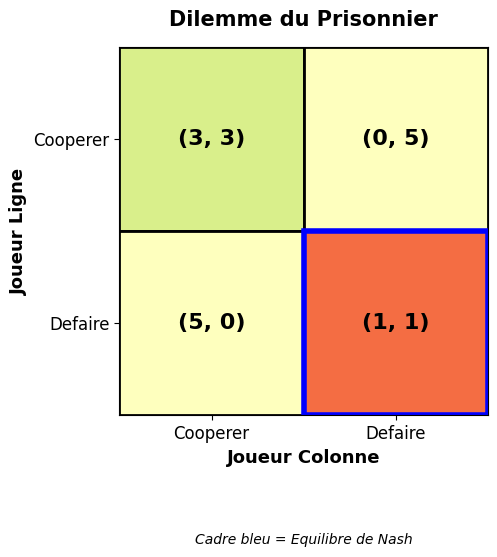

In [17]:
# Visualiser le Dilemme du Prisonnier
# L'equilibre de Nash est en (1, 1) = (Defaire, Defaire)
plot_payoff_matrix(
    A, B, 
    title="Dilemme du Prisonnier",
    labels=['Cooperer', 'Defaire'],
    highlight_nash=(1, 1)
)

**Observation** : La cellule (C, C) est la plus verte (gain total = 6), mais l'equilibre de Nash est (D, D) en jaune-orange (gain total = 2). C'est le coeur du dilemme !

***

## 7. Autres jeux classiques

Modifiez les gains pour créer d'autres jeux celebres. Utilisez `support_enumeration()` pour trouver leurs equilibres.

### Exercice 1 : Jeu de coordination (Stag Hunt)

Dans la **Chasse au cerf**, deux chasseurs peuvent :
- Chasser le cerf ensemble (necessite cooperation) -> gain eleve
- Chasser le lievre seul (sur) -> gain moyen

Matrice suggeree :

| | C | D |
|--|---|---|
| **C** | (4, 4) | (0, 3) |
| **D** | (3, 0) | (3, 3) |

In [18]:
# Exercice 1 : Stag Hunt
# Creez les matrices de gains A et B a partir du tableau ci-dessus,
# puis trouvez les equilibres de Nash.

# Exercice: Definir les matrices de gains A_stag et B_stag (np.array)
# Indice: A[i,j] = gain du joueur Ligne quand Ligne joue i et Colonne joue j


# Exercice: Creer le jeu et afficher les equilibres de Nash
# Indice: nash.Game(A, B) puis support_enumeration()


# Question: Combien d equilibres de Nash ce jeu a-t-il ?
print("Exercice a completer")

Exercice a completer


### Exemple guide : Jeu a somme nulle - Pierre-Feuille-Ciseaux (soumis par JertyanECE)

Dans un jeu a **somme nulle**, les gains d'un joueur sont exactement les pertes de l'autre : `A + B = 0`.

Matrice de Pierre-Feuille-Ciseaux (gain de Ligne) :

| | Pierre | Feuille | Ciseaux |
|--|--------|---------|--------|
| **Pierre** | 0 | -1 | 1 |
| **Feuille** | 1 | 0 | -1 |
| **Ciseaux** | -1 | 1 | 0 |

L'etudiant a implemente ce jeu et verifie que l'unique equilibre de Nash est en stratégies mixtes (1/3, 1/3, 1/3).

In [19]:
# Exemple guide : Pierre-Feuille-Ciseaux
# Soumis par JertyanECE (Jeremy Clement)

A_rps = np.array([[0, -1, 1],
                  [1, 0, -1],
                  [-1, 1, 0]])
B_rps = -A_rps  # Somme nulle

rps = nash.Game(A_rps, B_rps)
print("Equilibres de Nash de Pierre-Feuille-Ciseaux:")
for eq in rps.support_enumeration():
    print(eq)

# Reponse: L equilibre est en strategies mixtes (1/3, 1/3, 1/3)


Equilibres de Nash de Pierre-Feuille-Ciseaux:
(array([0.33333333, 0.33333333, 0.33333333]), array([0.33333333, 0.33333333, 0.33333333]))


### Interpretation : Equilibre en stratégies mixtes

**Résultat obtenu** : L'unique equilibre de Nash est `([1/3, 1/3, 1/3], [1/3, 1/3, 1/3])`.

**Signification** :
- Chaque joueur doit randomiser **uniformement** sur ses 3 actions
- Aucune action pure n'est preferable : si l'adversaire joue uniformement, chaque action donne un gain moyen de 0
- C'est la definition d'un jeu a somme nulle sans valeur sure

**Pourquoi 1/3 chacun ?**
- Si un joueur favorise une action (ex: Pierre plus souvent), l'adversaire peut l'exploiter en jouant Feuille
- L'uniformite est la seule stratégie indecelable (inexploitable)

> **Note technique** : Dans les jeux a somme nulle, les stratégies mixtes equilibrees sont souvent la norme car la randomisation elimine toute previsibilite.

### Exercice 2 : Jeu de la Poule Mouillee (Chicken Game)

Le jeu de la **Poule Mouillee** (ou Chicken Game) est un jeu d'anti-coordination classique.
Deux conducteurs foncent l'un vers l'autre. Chacun peut :
- **Devier** (Swerve) : eviter la collision, mais passer pour un lache
- **Continuer** (Straight) : maintenir le cap, risquer la catastrophe

Matrice des gains :

| | Devier | Continuer |
|--|--------|-----------|
| **Devier** | (0, 0) | (-1, 1) |
| **Continuer** | (1, -1) | (-5, -5) |

**Questions** :
1. Definissez les matrices de gains `A_chicken` et `B_chicken`
2. Créez le jeu avec `nash.Game(A_chicken, B_chicken)`
3. Trouvez les equilibres de Nash en stratégies pures avec `support_enumeration()`
4. Combien d'equilibres purs ce jeu possede-t-il ? Existe-t-il un equilibre mixte ?
5. Comparez avec le RPS : quelles différences structurelles observez-vous ?

**Indice** : Contrairement au RPS (somme nulle), ce jeu n'est PAS a somme nulle. Verifiez que `A + B != 0`.

In [20]:
# Exercice 2 : Jeu de la Poule Mouillee (Chicken Game)

# Exercice: Definir les matrices de gains A_chicken et B_chicken (np.array)
# A_chicken[i,j] = gain du joueur Ligne quand Ligne joue i et Colonne joue j
# Actions: 0 = Devier, 1 = Continuer


# Exercice: Creer le jeu bimatriciel avec nash.Game(A_chicken, B_chicken)


# Exercice: Trouver et afficher tous les equilibres de Nash
# Indice: utilisez support_enumeration() et affichez chaque equilibre


# Exercice: Verifier que ce n'est PAS un jeu a somme nulle
# Indice: calculez A_chicken + B_chicken et verifiez s'il contient des zeros partout


# Exercice: Visualiser la matrice avec la fonction plot_payoff_matrix si disponible
print("Exercice a completer")

Exercice a completer


### Exercice 3 : Bataille des Sexes (Battle of the Sexes)

Deux partenaires (Alice et Bob) veulent passer la soiree ensemble mais preferent des activites différentes : Alice prefere l'Opera, Bob prefere le Football. Tous deux preferent cependant etre ensemble que separes.

Matrice des gains (Alice = Ligne, Bob = Colonne) :

|              | Opera (Bob) | Football (Bob) |
|--------------|-------------|----------------|
| **Opera (Alice)**    | (3, 2) | (1, 1) |
| **Football (Alice)** | (0, 0) | (2, 3) |

Ce jeu se distingue du Stag Hunt et du Chicken Game : il admet **trois** equilibres de Nash (deux en stratégies pures, un en stratégies mixtes). C'est l'exemple canonique de *jeu de coordination* avec conflit de préférences.

> **Question** : Combien d'equilibres de Nash ce jeu admet-il ? Identifiez les deux equilibres purs, puis l'equilibre mixte.

In [21]:
# Exercice 3 : Bataille des Sexes (Battle of the Sexes)
# Ce jeu admet 3 equilibres de Nash : 2 purs + 1 mixte.

# Exercice: Definir les matrices de gains A_bos et B_bos (np.array)
# A_bos[i,j] = gain d'Alice, B_bos[i,j] = gain de Bob
# Indice: Alice en lignes [Opera, Football], Bob en colonnes [Opera, Football]
#   (Opera, Opera)       -> Alice 3, Bob 2
#   (Opera, Football)    -> Alice 1, Bob 1
#   (Football, Opera)    -> Alice 0, Bob 0
#   (Football, Football) -> Alice 2, Bob 3


# Exercice: Creer le jeu bimatriciel avec nash.Game(A_bos, B_bos)


# Exercice: Trouver et afficher TOUS les equilibres de Nash via support_enumeration()
# Indice: il doit y en avoir 3 (deux purs, un mixte).


# Question: Identifiez l'equilibre en strategies mixtes.
# Indice: dans l'equilibre mixte, chaque joueur randomise entre Opera et Football
# avec une probabilite strictement comprise entre 0 et 1.
print("Exercice a completer : Battle of the Sexes")

Exercice a completer : Battle of the Sexes


***

## 8. Prochaines étapes

L'environnement est maintenant configure. Voici la suite de la serie :

| Notebook | Contenu | Concepts cles |
|----------|---------|---------------|
| **GameTheory-02-NormalForm-Python** | Jeux en forme normale | Dominance, best response, rationalite |
| **GameTheory-03-Topology2x2-Python** | Classification des jeux 2x2 | Table periodique de Robinson-Goforth |
| **GameTheory-04-NashEquilibrium-Python** | Equilibres Nash | Stratégies mixtes, calcul, existence |

### Points cles a retenir

1. Un **jeu** est défini par des joueurs, des actions, et des gains
2. Un **equilibre de Nash** est stable : personne ne veut devier seul
3. L'equilibre n'est pas forcement optimal collectivement (cf. Dilemme du Prisonnier)
4. **Nashpy** permet de calculer les equilibres avec `support_enumeration()`

***

**Notebook suivant** : [GameTheory-02-NormalForm-Python](GameTheory-02-NormalForm-Python.ipynb)

## Conclusion

Ce notebook a installe l'environnement necessaire pour la serie GameTheory et introduit les concepts fondamentaux via le **Dilemme du Prisonnier**.

### Ce que nous avons mis en place

| Outil | Version | Rôle |
|-------|---------|------|
| **Nashpy** | (cf. cellule) | Calcul d'equilibres de Nash (support enumeration) |
| **OpenSpiel** | 122 jeux | Jeux simultanes, séquentiels, information imparfaite |
| **NetworkX** | (cf. cellule) | Visualisation de graphes de jeux |

### Premier résultat : le paradoxe du Prisonnier

Avec la matrice classique A=`[[3,0],[5,1]]`, B=`[[3,5],[0,1]]`, l'equilibre de Nash unique est **(Defaut, Defaut)** avec gains **(1, 1)**. Pourtant, la cooperation mutuelle donne **(3, 3)**, qui Pareto-domine. Ce paradoxe illustre le coeur de la théorie des jeux : rationalite individuelle vs optimum collectif.

Pierre-Feuille-Ciseaux montre un equilibre mixte **uniforme** : chaque joueur joue chaque coup avec probabilite 1/3.

**Suite** : [GT-2 - Forme normale](GameTheory-02-NormalForm-Python.ipynb) | [Retour au sommaire](README.md)

***

### Aide-mémoire : installation selon votre plateforme

La cellule suivante affiche la commande d'installation OpenSpiel adaptée à **votre**
machine détectée — miroir de l'aide-mémoire du [Lean-01-Setup-Lean-Python](../SymbolicAI/Lean/Lean-01-Setup-Lean-Python.ipynb).
Cellule informative : aucun changement de système, affichage uniquement.


In [22]:
# Aide-memoire : commande d'installation OpenSpiel selon la plateforme detectee.
# Cellule informative : aucun changement de systeme, affichage uniquement.

import platform

system = platform.system()
print("=" * 64)
print("    AIDE-MEMOIRE : installation OpenSpiel pour VOTRE machine")
print("=" * 64)
print()
print(f"OS detecte : {system}")
print()

if system == "Windows":
    print("Plateforme : Windows")
    print()
    print("  OpenSpiel n'a pas de wheel pip natif Windows. Deux voies :")
    print()
    print("  1. WSL (recommande) : suivre la section Configuration WSL")
    print("     de ce notebook (kernel gametheory-wsl configure automatiquement,")
    print("     Windows uniquement).")
    print()
    print("  2. Fallback Python pur : le notebook fonctionne sans OpenSpiel")
    print("     via game_theory_utils.py (sections suivantes).")
elif system in ("Darwin", "Linux"):
    nom = "macOS" if system == "Darwin" else "Linux"
    print(f"Plateforme : {nom}")
    print()
    print("  # Installation directe (elan/pip natifs, pas de WSL)")
    print("  pip install open_spiel")
    print()
    print("  Puis relancer ce notebook : la cellule de detection (section 1)")
    print("  confirmera le nombre de jeux disponibles.")
else:
    print(f"Plateforme non reconnue : {system}")
    print("  Consulter la table 'Plateformes supportees' en tete de notebook.")


    AIDE-MEMOIRE : installation OpenSpiel pour VOTRE machine

OS detecte : Windows

Plateforme : Windows

  OpenSpiel n'a pas de wheel pip natif Windows. Deux voies :

  1. WSL (recommande) : suivre la section Configuration WSL
     de ce notebook (kernel gametheory-wsl configure automatiquement,
     Windows uniquement).

  2. Fallback Python pur : le notebook fonctionne sans OpenSpiel
     via game_theory_utils.py (sections suivantes).
